# Analysis 2: Self-similarity vs ideological similarity

For each respondent:

    * Identify qs which are ideologically aligned v. not (ie: if Dem, likes about Dem cand)
    * Compare similarity of network structure between aligned v. not aligned qs
    * Identify comparison set of users with same ideology
    * Compare similarity of network structure between same qs

In [1]:
import pandas as pd
import numpy as np
import scipy.stats as sp
import ast
import itertools as it
import json

import networkx as nx
import netrd
dist_obj = netrd.distance.PortraitDivergence()

import matplotlib.pyplot as plt
import seaborn as sns

# Load and clean data

In [2]:
text_qs = ['V161069', # PRE: Text- What is it that R likes about Democratic Pres cand
           'V161072', # PRE: Text- What is it that R dislikes about Democratic Pres cand
           'V161075', # PRE: Text- What is it that R likes about Republican Pres cand
           'V161078', # PRE: Text- What is it that R dislikes about Republican Pres cand
           'V161098', # PRE: Text- What does R like about Democratic party
           'V161101', # PRE: Text- What does R dislike about the Democratic party
           'V161104', # PRE: Text- What does R like about Republican party
           'V161106'  # PRE: Text- What does R dislike about the Republican party
          ]

### Convert network columns to dict on load

In [3]:
def to_dict(x):
    try:
        y = ast.literal_eval(x)
        if isinstance(y, dict):  # Ensure it's actually a dictionary
            return y
    except (ValueError, SyntaxError):
        return None  # Or handle the error as needed

In [4]:
net_cols = [f'{q}_network' for q in text_qs]

data = pd.read_csv('network_data.csv', converters=dict((col, to_dict) for col in net_cols))

In [5]:
# clean part id
pids = {0: 0, 1: 0, # Dem
        2: 1, 3: 1, 4: 1, # Ind 
        5: 2, 6: 2, # Rep
        '': np.nan # missing
       }
    
data['party_id'] = data['leftright'].fillna('').apply(lambda x: pids[x])

# rename subject_id
data = data.rename(columns={'V160001':'subj_id'})

In [6]:
# reshape data
cols = ['subj_id', 'party_id']

df = data[cols + net_cols].melt(id_vars=cols, value_vars=net_cols, 
                                var_name='question',
                                value_name='network')

# drop rows with no nodes / edges
df = df[df['network'].apply(lambda x: len(x['nodes']) > 1 and len(x['edges']) > 0)]
print(f'{len(df)} observations')

14568 observations


In [7]:
# reset index twice, rename to obs_id
df = df.reset_index()
df = df[df.columns[1:]] # drop old index col
df = df.reset_index()
df = df.rename(columns={'index': 'obs_id'}) # contiguous obs id

# Construct Networkx objects for each network

In [91]:
def get_network(network):
    nodes = network['nodes']
    edges = network['edges']
    
    G = nx.Graph()
    G.add_weighted_edges_from(edges)

    for node in nodes:
        G.add_node(node)

    return G

In [92]:
n = len(df) # num unique networks
networks = dict() # {obs_id : G}

for i, row in df.iterrows():
    G = get_network(row['network'])

    # save to dict
    networks[i] = G

In [8]:
# for each SUBJECT determine self + comparison networks
comparisons = dict()

for subj in set(df['subj_id']):
    comparisons.setdefault(subj, dict())
    
    ##### Self data ####
    self_data = df[df['subj_id']==subj]
    self_obs = self_data['obs_id'].values # keys for my own networks
    
    # save self data
    comparisons[subj]['self'] = self_obs

    ##### comparisons  ####
    
    # my party id
    pid = self_data['party_id'].values[0]
    
    # the questions I answered
    qs = self_data['question'] # {obs_id : q}

    # responses from same party_id, but not me
    party_sub = df[(df['party_id']==pid) & (df['subj_id']!=subj)]
    
    # for each question
    for i, q in qs.items():
        comparisons[subj].setdefault('comp', dict())
        
        # obs_id of comparison networks
        comp = party_sub[party_sub['question']==q]['obs_id'].values
        
        # {my_network_for_q : comparison_networks_for_same_q}
        comparisons[subj]['comp'][i] = comp

print(f'{len(comparisons)} unique subjects found')

3820 unique subjects found


# Calculate distances

In [53]:
N = 2
print(int((N * (N - 1)) / 2))

N = 8
print(int((N * (N - 1)) / 2))

1
28


In [156]:
distances = dict()

for count, subj in enumerate(comparisons):
    if count%1000==0:
        print(f'Processing subject #{count}')
    
    distances.setdefault(subj, dict())
    
    #### self networks
    nets = comparisons[subj]['self']
    N = len(nets)
    combs = int((N * (N - 1)) / 2)
    dists = np.zeros(combs)
    
    for x, (i, j) in enumerate(it.combinations(nets, 2)):
        # network i
        G = networks[i]

        # network j
        H = networks[j]

        # calculate distance
        dist = dist_obj.dist(G, H)
        
        # save distance
        dists[x] = dist
    
    # save all self-distances
    distances[subj]['self'] = dists
    
    ###### Comparison networks ####
    net_dict = comparisons[subj]['comp']
    dist_lists = list()
    
    for i, comps in net_dict.items():
        N = len(comps)
        combs = int((N * (N - 1)) / 2)
        q_dists = np.zeros(combs)
        
        # network i (subj network)
        G = networks[i]
        
        # network j (network from user w same pid, same q)
        for x, j in enumerate(comps):
            H = networks[j]
            
            # calculate distance
            dist = dist_obj.dist(G, H)
            
            # save distances for this q
            q_dists[x] = dist
        
        # append dists to this question
        dist_lists.append(q_dists)
        
    # save all comparison distances
    dists = np.concatenate(dist_lists)
    distances[subj]['comp'] = dists

Processing subject #0
Processing subject #1000
Processing subject #2000
Processing subject #3000


In [162]:
conv = dict()

for k, vs in distances.items():
    conv.setdefault(k, dict())
    
    for mode, v in vs.items():
        conv[k][mode] = list(v)

In [163]:
with open('distances.json', 'w') as fp:
    fp.write(json.dumps(conv))

### Re-Load distances

In [8]:
# load distances
with open('distances.json', 'r') as fp:
    distances = json.loads(fp.read())

# Plot distances

In [9]:
def get_cumulative(data, nb, log=False):
    # Find upper and lower bounds
    lower_bound = min(data)
    upper_bound = max(data) + 1

    # define bins
    if log:
        lower_bound = np.log10(lower_bound) if lower_bound > 0 else 0
        upper_bound = np.log10(upper_bound)
        bins = np.logspace(lower_bound, upper_bound, nb)
    else:
        bins = np.linspace(lower_bound, upper_bound, nb)
        
    # compute the midpoint of each bin
    sx = bins[1:] - np.diff(bins) / 2.0          
    
    bin_width = bins[1:] - np.diff(bins)
    
    # compute the height of each bin
    sy, __ = np.histogram(data, bins = bins, density = True)
    
    # From graph above, vector y holds log-binned values of p_1...p_k
    # For cumulative distribution, we want a vector in which:
    # p_1 = p_2 + p_3 + ... + p_k

    bin_width = sy * np.diff(bins)
    cum_sum = np.cumsum(bin_width[::-1]) #sum the reversed p_k distribution

    return sx, cum_sum[::-1] # return the reverse of the cumulative sum

In [10]:
def binning(data,nb=50,log=True):
    # Seperate a vector of data into linear or log bins

    # Input:
    #   data : a vector of data
    #   bins : the number of bins to output (default: 50) 
    #   log : whether to log bin the data (default: True)

    # Output:
    #   x : the the midpoint of each bin
    #   y: the height of each bin 


    # 1. find the data's upper and lower bounds
    lower_bound = min(data)
    upper_bound = max(data) + 1

    # 2. Define bins
    if log:
        lower_bound = np.log10(lower_bound) if lower_bound > 0 else 0
        upper_bound = np.log10(upper_bound)
        bins = np.logspace(lower_bound, upper_bound, nb)

    else:
        bins = np.linspace(lower_bound, upper_bound, nb)
    
    # 3. Compute the midpoint of each bin
    x = bins[1:] - np.diff(bins) / 2.0 

    # 4. Compute the height of each bin
    y, __ = np.histogram(data, bins = bins, density=False)

    # fix numpy density issue
    y = y / np.sum(y)

    return x, y

## AVG using a similar sample size

In [11]:
self_vals = dict()
comp_avg = dict()
comp_high = dict()
comp_low = dict()

samps = 100

for val in ['All','Dem', 'Ind', 'Rep']:
    self_vals.setdefault(val, list())
    comp_avg.setdefault(val, list())
    comp_high.setdefault(val, list())
    comp_low.setdefault(val, list())


for subj, comps in distances.items():
    pid = df[df['subj_id']==int(subj)]['party_id'].values[0]

    if pid == 0:
        party = 'Dem'
    elif pid == 1:
        party = 'Ind'
    elif pid == 2:
        party = 'Rep'

    self = comps['self']
    self = [val for val in self if val > 0]
    
    comp = comps['comp']
    comp = [val for val in comp if val > 0]
    
    if len(self) > 1 and len(comp) > 1:
        ##### self comparison
        n = len(self) # number of comparisons made

        avg = np.mean(self)
        
        if avg == avg:
            self_vals['All'].append(avg)
            self_vals[party].append(avg)
            
        ##### comparison
        avgs = np.zeros(samps)

        for i in range(samps):
            samp = np.random.choice(comp, n)
            avgs[i] = np.mean(samp)

        # add average of average + high and low
        avgs = avgs[~np.isnan(avgs)]
        
        comp_avg['All'].append(np.mean(avgs))
        comp_high['All'].append(np.percentile(avgs, 97.5))
        comp_low['All'].append(np.percentile(avgs, 2.5))
        
        comp_avg[party].append(np.mean(avgs))
        comp_high[party].append(np.percentile(avgs, 97.5))
        comp_low[party].append(np.percentile(avgs, 2.5))
    
print('calculations complete')

calculations complete


In [12]:
for val in ['All','Dem', 'Ind', 'Rep']:
    print(f'Checking {val}...')
    result = sp.ttest_ind(self_vals[val], comp_avg[val]).pvalue
    if result < 0.05:
        print('\tDistributions are significantly different with p=%.5f' % result)
    else:
        print('\tDistributions not significantly different with p=%.3f' % result)

Checking All...
	Distributions are significantly different with p=0.00000
Checking Dem...
	Distributions are significantly different with p=0.00000
Checking Ind...
	Distributions are significantly different with p=0.00000
Checking Rep...
	Distributions are significantly different with p=0.00000


In [49]:
print(f'Comparing Self to low (All)')
result = sp.ttest_ind(self_vals['All'], comp_low['All']).pvalue
if result < 0.05:
    print('\tDistributions are significantly different with p=%.5f' % result)
else:
    print('\tDistributions not significantly different with p=%.3f' % result)

Comparing Self to low (All)
	Distributions are significantly different with p=0.00000


In [52]:
print(f'  Self avg: {np.mean(self_vals["All"])}')
print(f'  Other avg: {np.mean(comp_low["All"])}\n')

  Self avg: 0.3001896281381336
  Other avg: 0.2222481603832



In [55]:
comp_min = min(comp_avg['All'])
print(comp_min)

0.22885965402435116


In [58]:
### self distances less than comp_min
small = [val for val in self_vals['All'] if val < comp_min]
print(f'{len(small)} ({len(small)/len(self_vals["All"]):.2%}) respondents more self-similar than comp min')

648 (24.01%) respondents more self-similar than comp min


In [59]:
max(comp_avg['All'])

0.7075327727870395

In [60]:
max(self_vals['All'])

0.6455671538225853

In [13]:
for val in ['All','Dem', 'Ind', 'Rep']:
    print(f'Checking {val}...')
    print(f'  Self avg: {np.mean(self_vals[val])}')
    print(f'  Other avg: {np.mean(comp_avg[val])}\n')

Checking All...
  Self avg: 0.3001896281381336
  Other avg: 0.3387128345454641

Checking Dem...
  Self avg: 0.2995583575170513
  Other avg: 0.3391648053469709

Checking Ind...
  Self avg: 0.3011906892981602
  Other avg: 0.3385617824462914

Checking Rep...
  Self avg: 0.2997817780487125
  Other avg: 0.3383657096276332



# Plot

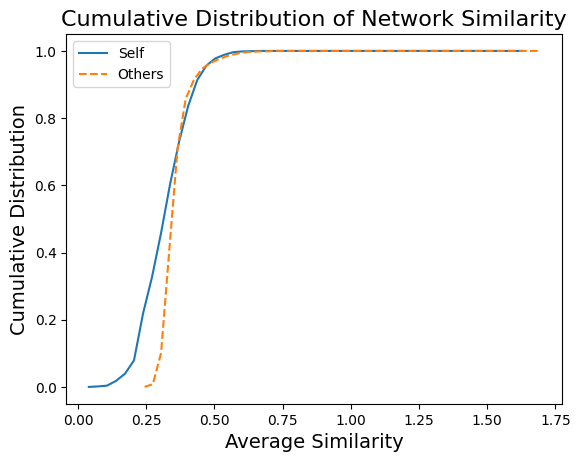

In [14]:
# plot
x, y = get_cumulative(self_vals['All'], nb=50)
y = [1 - num for num in y]
plt.plot(x, y, label='Self')

x, y = get_cumulative(comp_avg['All'], nb=50)
y = [1 - num for num in y]
plt.plot(x, y, ls='--', label='Others')

plt.title('Cumulative Distribution of Network Similarity', size=16)

plt.xlabel('Average Similarity', size=14)
plt.ylabel('Cumulative Distribution', size=14)

plt.legend()

plt.savefig('NetSim_all_cum.png', dpi=300, bbox_inches='tight')
plt.show()

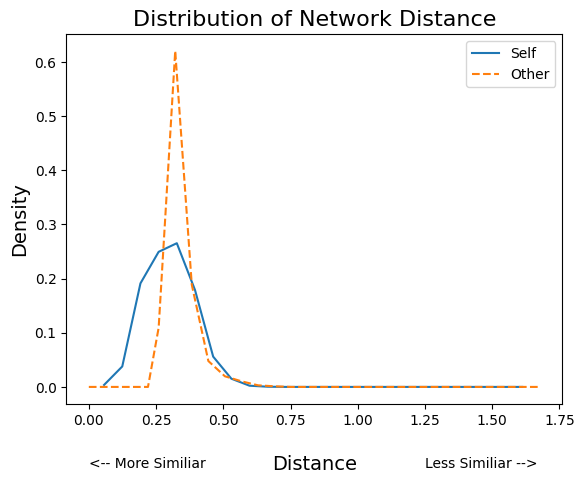

In [61]:
x, y = binning(self_vals['All'], nb=25, log=False)
plt.plot(x,y, label='Self')


x, y = binning(comp_avg['All'], nb=25, log=False)
x = np.insert(x, 0, .22)
x = np.insert(x, 0, 0)

y = np.insert(y, 0, 0)
y = np.insert(y, 0, 0)

plt.plot(x,y, ls='--', label='Other')


plt.text(0, -.15, '<-- More Similiar')
plt.text(1.25, -.15, 'Less Similiar -->')


plt.title(f'Distribution of Network Distance', size=16)

plt.xlabel('\nDistance', size=14)
plt.ylabel('Density', size=14)

plt.legend()
plt.savefig('NetSim.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
x, y = binning(self_vals['All'], nb=25, log=False)
plt.plot(x,y, label='Self')


x, y = binning(comp_avg['All'], nb=25, log=False)
x = np.insert(x, 0, .24)
x = np.insert(x, 0, 0)

y = np.insert(y, 0, 0)
y = np.insert(y, 0, 0)

plt.plot(x,y, ls='--', label='Other')


plt.text(0, -.15, '<-- More Similiar')
plt.text(1.25, -.15, 'Less Similiar -->')


plt.title(f'Distribution of Network Distance', size=16)

plt.xlabel('\nDistance', size=14)
plt.ylabel('Density', size=14)

plt.legend()
plt.savefig('NetSim.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
comp_high = dict()
comp_low = dict()

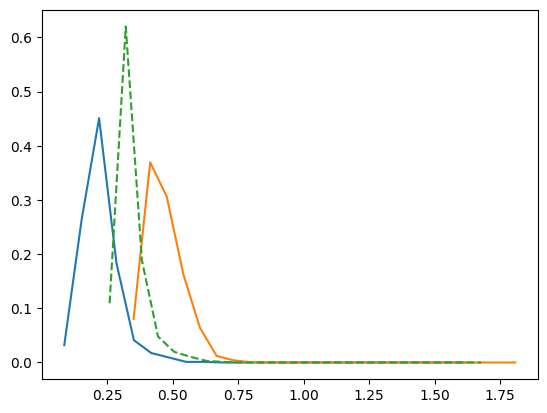

In [47]:
x1, y1 = binning(comp_low['All'], nb=25, log=False)
x2, y2 = binning(comp_high['All'], nb=25, log=False)

x, y = binning(comp_avg['All'], nb=25, log=False)

plt.plot(x1,y1)
plt.plot(x2,y2)
plt.plot(x,y, ls='--', label='Other')


plt.show()

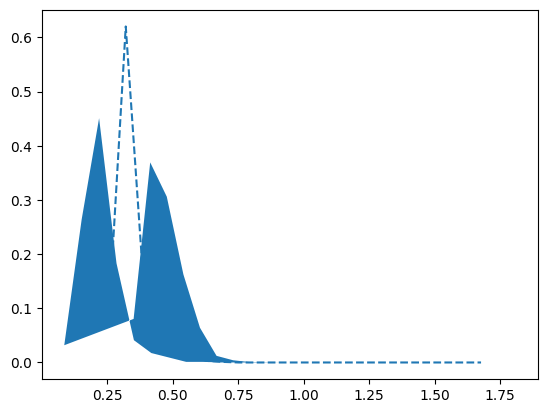

In [46]:
x2, y2 = binning(comp_high['All'], nb=25, log=False)
x1, y1 = binning(comp_low['All'], nb=25, log=False)

fill_x = np.concatenate((x1, x2[::-1]))
fill_y = np.concatenate((y1, y2[::-1]))

plt.fill(fill_x, fill_y)

x, y = binning(comp_avg['All'], nb=25, log=False)

plt.plot(x,y, ls='--', label='Other')


plt.show()

In [40]:
x1

array([0.35124795, 0.41453774, 0.47782753, 0.54111732, 0.60440711,
       0.6676969 , 0.73098669, 0.79427648, 0.85756627, 0.92085606,
       0.98414585, 1.04743564, 1.11072543, 1.17401522, 1.23730501,
       1.3005948 , 1.36388459, 1.42717438, 1.49046417, 1.55375396,
       1.61704375, 1.68033354, 1.74362333, 1.80691312])

In [41]:
x2

array([0.08670963, 0.15313763, 0.21956562, 0.28599362, 0.35242161,
       0.41884961, 0.48527761, 0.5517056 , 0.6181336 , 0.68456159,
       0.75098959, 0.81741758, 0.88384558, 0.95027358, 1.01670157,
       1.08312957, 1.14955756, 1.21598556, 1.28241355, 1.34884155,
       1.41526954, 1.48169754, 1.54812554, 1.61455353])

In [42]:
comp_high['All']

[0.58851299526863,
 0.5429460094556373,
 0.4488530291403709,
 0.4637369590274202,
 0.5286948066780112,
 0.6726880787503924,
 0.7499708812056075,
 0.4033095659040465,
 0.39864417384238005,
 0.4305208994760215,
 0.34785423026284673,
 0.5279555193718306,
 0.46262669842179055,
 0.41019191494334273,
 0.5210568564954775,
 0.5065187777015683,
 0.45117623671034585,
 0.4733791096339533,
 0.43791924570962487,
 0.48271576845841463,
 0.415035176089349,
 0.41009668599638205,
 0.4116019038328886,
 0.42444135673475736,
 0.5111514862507794,
 0.5389625946989822,
 0.4958837273659461,
 0.4545017304918469,
 0.47076915527768526,
 0.6097002907858176,
 0.4139960009636271,
 0.43544577460488954,
 0.46156890493518893,
 0.42329515217148134,
 0.4859965243877614,
 0.5241227845486124,
 0.5971861889403085,
 0.537770679288386,
 0.3692978105203184,
 0.5704096038771641,
 0.5862885797132733,
 0.3708898305900416,
 0.3864035556373873,
 0.4467852811225107,
 0.47328492698449093,
 0.42201579843964054,
 0.4632014999671111,
 0

In [43]:
comp_low['All']

[0.1973706036389829,
 0.2933606626662433,
 0.22662687176895965,
 0.18821007996130978,
 0.31557570881012353,
 0.36304056573376303,
 0.2952763614781954,
 0.152586424322365,
 0.25839849779422713,
 0.22381620767017638,
 0.19519434737032296,
 0.17179370206939612,
 0.3220651620220292,
 0.2456236167803277,
 0.3605299128669241,
 0.2254568499071465,
 0.20692260316004352,
 0.28058112542602387,
 0.14965331563997514,
 0.3460154251689881,
 0.2518890611455883,
 0.22078701406741763,
 0.21869221263242933,
 0.24856936188034653,
 0.2461860295194715,
 0.23461736026696448,
 0.3156390426596446,
 0.10859555722254467,
 0.20280492238727896,
 0.3610164459857704,
 0.23947958653303447,
 0.21454313496368893,
 0.2772817097840235,
 0.2502848439471849,
 0.25930344453876353,
 0.16208256626051115,
 0.32268063159594507,
 0.3854119431440211,
 0.25536572736473956,
 0.23505198149575246,
 0.28298629135529746,
 0.22914628816892885,
 0.2260036036337396,
 0.2323123723841781,
 0.2240840787227384,
 0.2999652803087118,
 0.209598

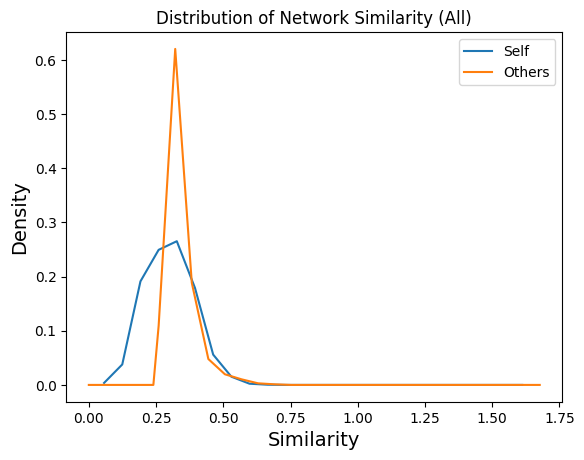

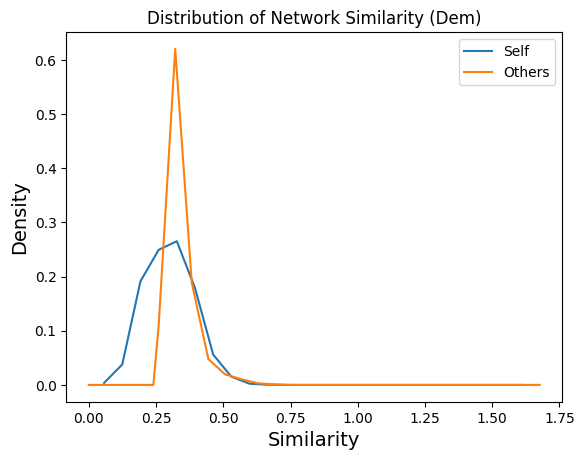

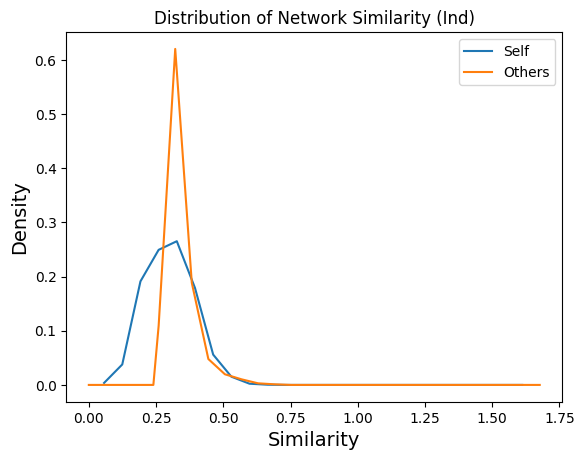

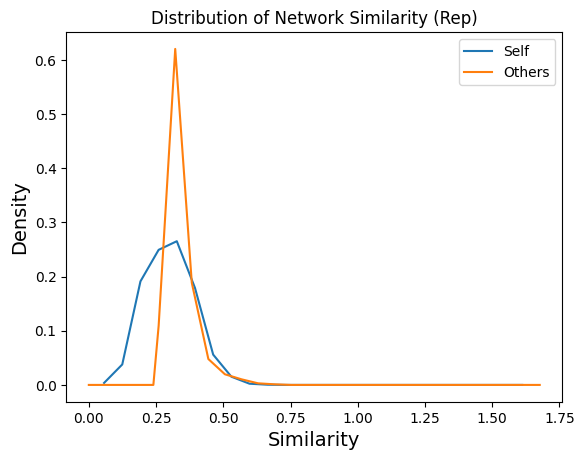

In [22]:
for val in ['All','Dem', 'Ind', 'Rep']:

    x, y = binning(self_vals['All'], nb=25, log=False)
    plt.plot(x, y, label='Self')

    x, y = binning(comp_avg['All'], nb=25, log=False)
    x = np.insert(x, 0, .24)
    x = np.insert(x, 0, 0)

    y = np.insert(y, 0, 0)
    y = np.insert(y, 0, 0)

    plt.plot(x, y, label='Others')
    
    plt.title(f'Distribution of Network Similarity ({val})')
    
    plt.xlabel('Similarity', size=14)
    plt.ylabel('Density', size=14)

    plt.legend()
    plt.show()


## Old code

In [65]:
self_vals = list()
comp_avg = list()
comp_high = list()
comp_low = list()

samps = 100

for subj, comps in distances.items():
    self = comps['self']
    self = [val for val in self if val > 0]
    
    comp = comps['comp']
    comp = [val for val in comp if val > 0]
    
    if len(self) > 1 and len(comp) > 1:
        ##### self comparison
        n = len(self) # number of comparisons made

        avg = np.mean(self)
        
        if avg == avg:
            self_vals.append(avg)

        ##### comparison
        avgs = np.zeros(samps)

        for i in range(samps):
            samp = np.random.choice(comp, n)
            avgs[i] = np.mean(samp)

        # add average of average + high and low
        avgs = avgs[~np.isnan(avgs)]
        comp_avg.append(np.mean(avgs))
        comp_high.append(np.percentile(avgs, 97.5))
        comp_low.append(np.percentile(avgs, 2.5))
    
print('calculations complete')

calculations complete


	Distributions are significantly different with p=0.00000


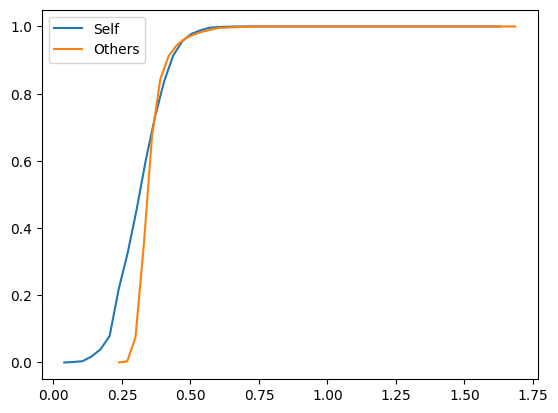

In [66]:
######## All comparisons (AVG)

x, y = get_cumulative(self_vals, nb=50)
y = [1 - num for num in y]
plt.plot(x, y, label='Self')

x, y = get_cumulative(comp_avg, nb=50)
y = [1 - num for num in y]
plt.plot(x, y, label='Others')
    
plt.legend()
plt.show()

In [18]:
avgs = dict()
stds = dict()

for val in ['All', 'Dem', 'Ind', 'Rep']:
    avgs.setdefault(val, dict())
    avgs[val].setdefault('self', list())
    avgs[val].setdefault('comp', list())
    
    stds.setdefault(val, dict())
    stds[val].setdefault('self', list())
    stds[val].setdefault('comp', list())

for subj, comps in distances.items():
    pid = df[df['subj_id']==int(subj)]['party_id'].values[0]
    
    if pid == 0:
        party = 'Dem'
    elif pid == 1:
        party = 'Ind'
    elif pid == 2:
        party = 'Rep'
        
    for mode in ['self', 'comp']:  
        vals = comps[mode]
        
        vals = [val for val in vals if val > 0]
        
        try:
            avg = np.mean(vals)
            std = np.std(vals)

            if avg == avg:
                avgs['All'][mode].append(avg)
                avgs[party][mode].append(avg) 

            if std == std:
                stds['All'][mode].append(std)
                stds[party][mode].append(std) 
        except RuntimeWarning:
            pass

print('calculations complete')

/Users/ss4316/.pyenv/versions/3.10.6/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3464: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/ss4316/.pyenv/versions/3.10.6/lib/python3.10/site-packages/numpy/core/_methods.py:192: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/ss4316/.pyenv/versions/3.10.6/lib/python3.10/site-packages/numpy/core/_methods.py:269: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/ss4316/.pyenv/versions/3.10.6/lib/python3.10/site-packages/numpy/core/_methods.py:226: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/Users/ss4316/.pyenv/versions/3.10.6/lib/python3.10/site-packages/numpy/core/_methods.py:261: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


calculations complete


### By party

In [68]:
for val in ['All','Dem', 'Ind', 'Rep']:
    print(f'Checking {val}...')
    result = sp.ttest_ind(self_vals[val], comp_avg[val]).pvalue
    if result < 0.05:
        print('\tDistributions are significantly different with p=%.5f' % result)
    else:
        print('\tDistributions not significantly different with p=%.3f' % result)


Checking All...
	Distributions are significantly different with p=0.00000
Checking Dem...
	Distributions are significantly different with p=0.00000
Checking Ind...
	Distributions are significantly different with p=0.00000
Checking Rep...
	Distributions are significantly different with p=0.00000


In [71]:
for val in ['All','Dem', 'Ind', 'Rep']:
    print(f'Checking {val}...')
    print(f'  Self avg: {np.mean(self_vals[val])}')
    print(f'  Other avg: {np.mean(comp_avg[val])}\n')

Checking All...
  Self avg: 0.3001896281381336
  Other avg: 0.3389012969810452

Checking Dem...
  Self avg: 0.2995583575170513
  Other avg: 0.33874050019150415

Checking Ind...
  Self avg: 0.3011906892981602
  Other avg: 0.3387253185713221

Checking Rep...
  Self avg: 0.2997817780487125
  Other avg: 0.33928434075383535



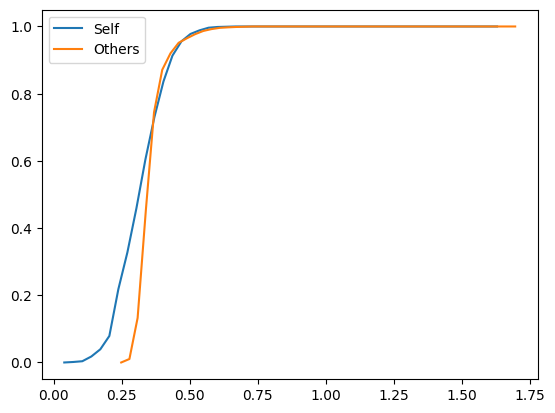

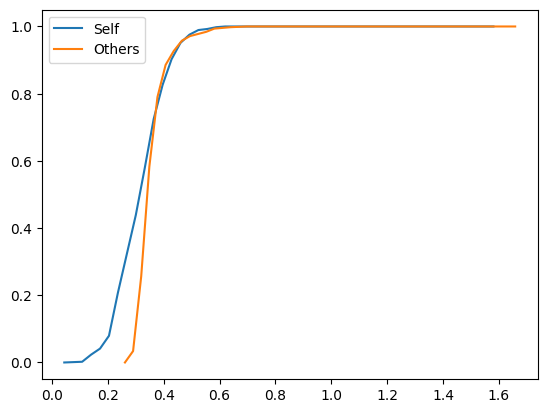

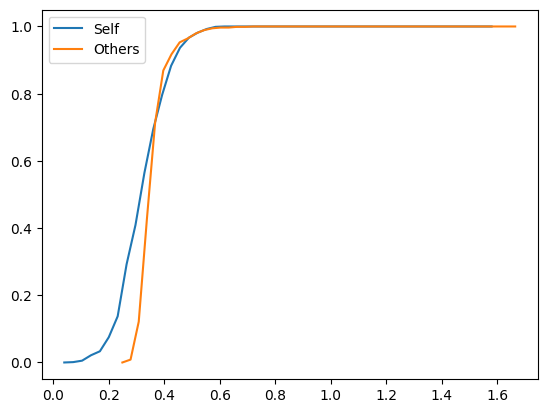

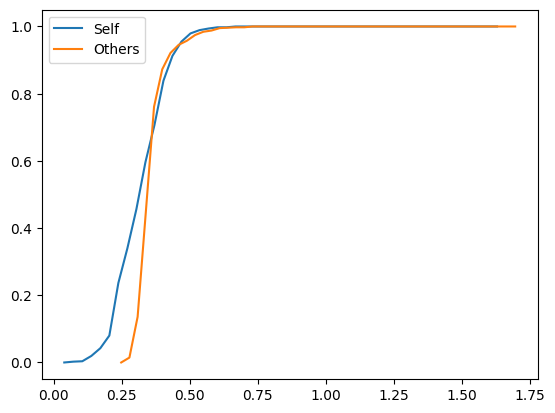

In [69]:
for val in ['All','Dem', 'Ind', 'Rep']:

    x, y = get_cumulative(self_vals[val], nb=50)
    y = [1 - num for num in y]
    plt.plot(x, y, label='Self')

    x, y = get_cumulative(comp_avg[val], nb=50)
    y = [1 - num for num in y]
    plt.plot(x, y, label='Others')

    plt.legend()
    plt.show()


	Distributions are significantly different with p=0.00000


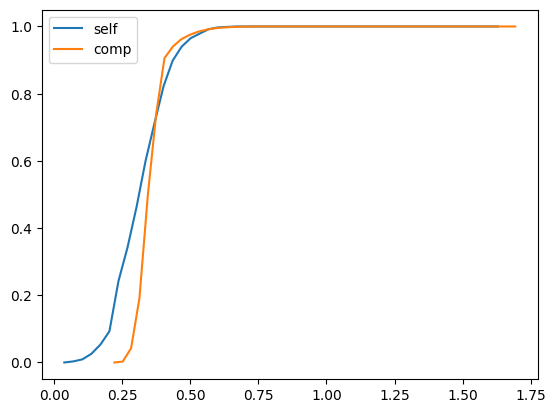

In [21]:
######## All comparisons (AVG)
self = avgs['All']['self']
comp = avgs['All']['comp']

# compare distributions
result = sp.ttest_ind(self, comp).pvalue
if result < 0.05:
    print('\tDistributions are significantly different with p=%.5f' % result)
else:
    print('\tDistributions not significantly different with p=%.3f' % result)


for mode in ['self', 'comp']:
    x, y = get_cumulative(avgs['All'][mode], nb=50)
    y = [1 - num for num in y]
    
    plt.plot(x, y, label=mode)
    
plt.legend()
plt.show()